__Markus Mulvihill__

__Last updated April 2026__

# Necessary Packages and Modules

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tomllib
import plt_config

# Introduction

Within this file, different methods of parameter estimation will be implemented and compared to predict the Insulin Sensitivity $\, SI$ in patients

# Integral-based Method Constant SI

In [30]:
try:
    SI_ests = np.load("../scripts/variables/SI_ests_integral_static_04.npy")
    SI_errs = np.load("../scripts/variables/SI_errs_integral_static_04.npy")
    SI_true_arr = np.load("../scripts/variables/SI_true_arr_integral_static_04.npy")
    print("Loaded variables")
except Exception:
    print("Run 04_Parameter_estimation_integral.py")

Loaded variables


In [31]:
total_mard = np.average(SI_errs, axis=(0,1))
print("Total MARD: ", total_mard)

Total MARD:  0.06142751737467808


# Integral-based Method Piecewise SI

In [32]:
try:
    SI_ests = np.load("../scripts/variables/SI_ests_integral_vary_04.npy")
    SI_errs = np.load("../scripts/variables/SI_errs_integral_vary_04.npy")
    SI_true_arr = np.load("../scripts/variables/SI_true_arr_integral_vary_04.npy")
    print("Loaded variables")
except Exception:
    print("Run 04_Parameter_estimation_integral_vary.py")

Loaded variables


In [33]:
total_mard = np.average(SI_errs, axis=(0,1))
print("Total MARD: ", total_mard)

Total MARD:  0.0625729895667034


# Constant SI with State Augmentation

In [34]:
try:
    SI_ests = np.load("../scripts/variables/SI_ests_augment_static_04.npy")
    SI_errs = np.load("../scripts/variables/SI_errs_augment_static_04.npy")
    SI_true_arr = np.load("../scripts/variables/SI_true_arr_augment_static_04.npy")
    # all_vars = np.load("../scripts/variables/vars_augment_static_04.npy")
    # states = np.load("../scripts/variables/states_augment_static_04.npy")
    print("Loaded variables")
except Exception:
    print("Run 04_Paramater_estimation_augment.py")

Loaded variables


In [35]:
with open("../config.toml", "rb") as f:
    cfg = tomllib.load(f)
curr_module = "04"
num_particles = cfg[curr_module]["num_particles"]
low_perc = cfg[curr_module]["low_perc"]
high_perc = cfg[curr_module]["high_perc"]
CI = cfg[curr_module]["CI"]
dev_perc = cfg[curr_module]["dev_perc"]
deviations = cfg[curr_module]["deviations"]
num_deviations = len(deviations)

filters = ["EKF"]
pfs = [f"PF {particles}" for particles in num_particles]
filters.extend(pfs)

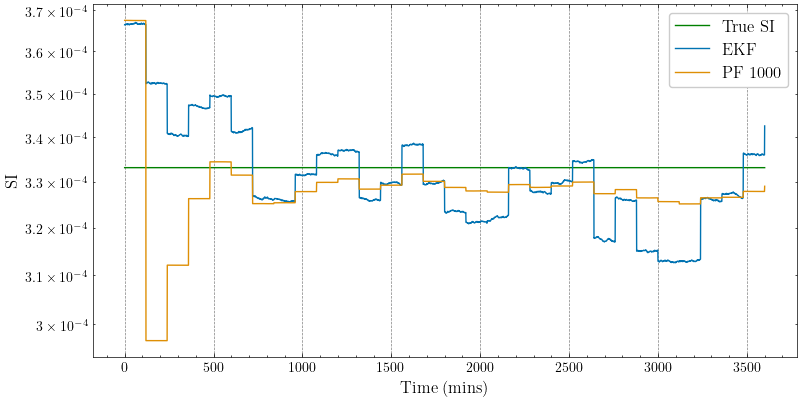

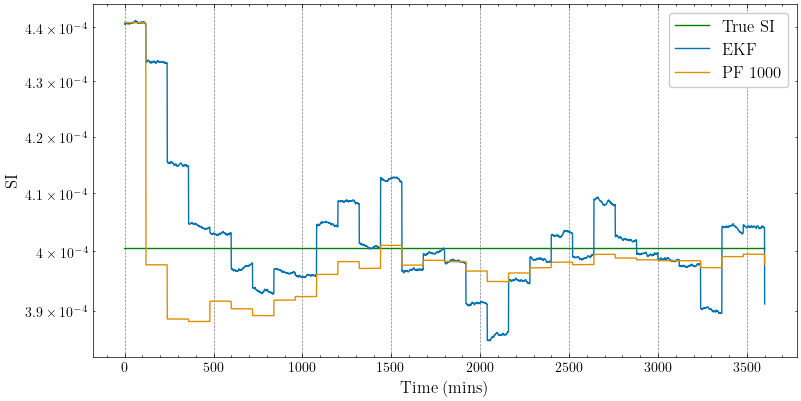

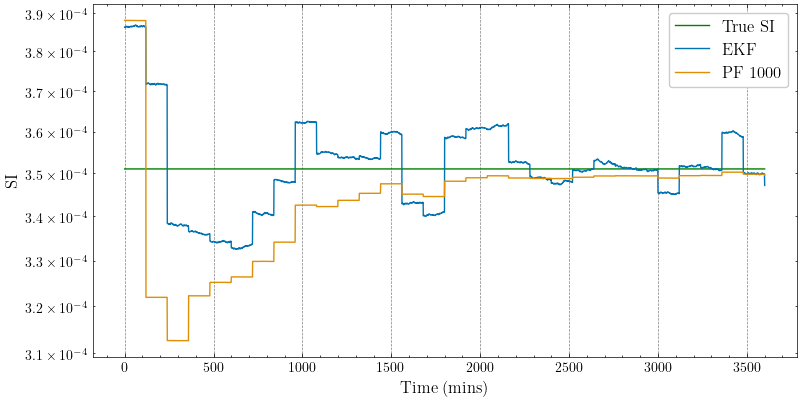

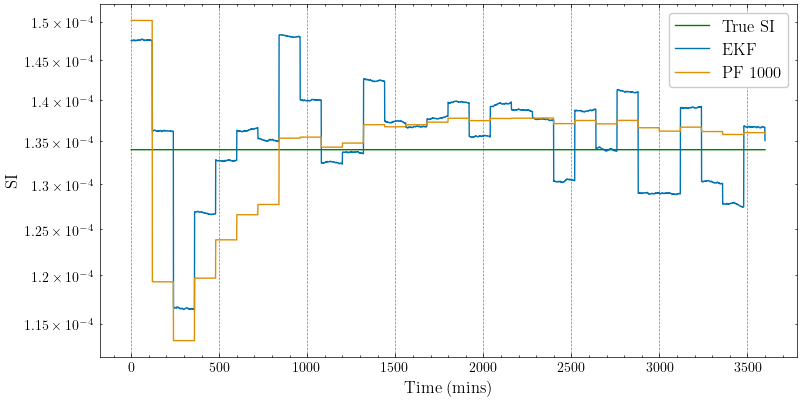

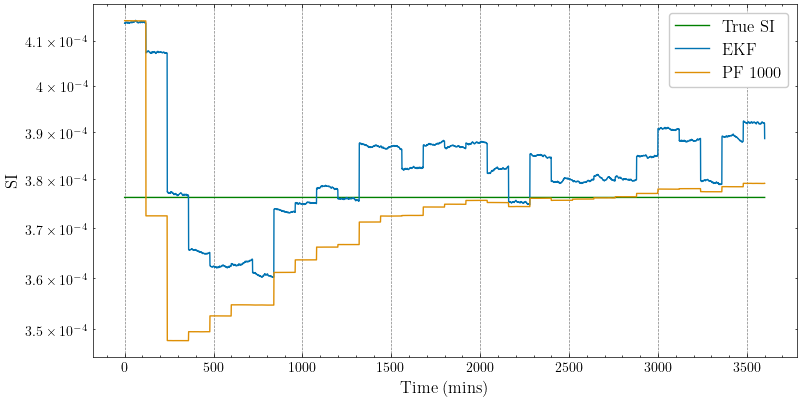

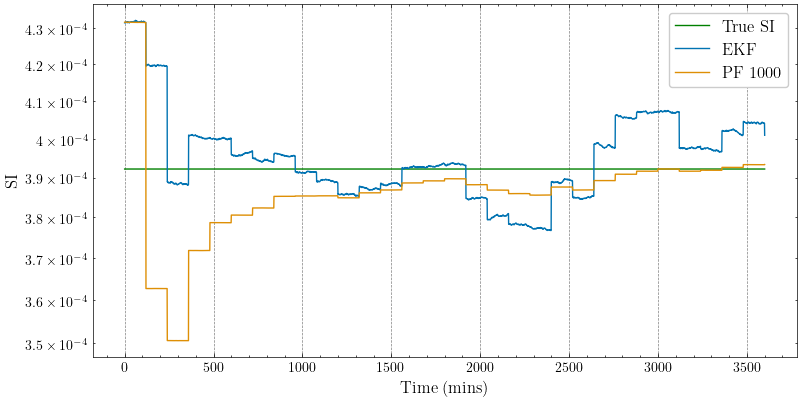

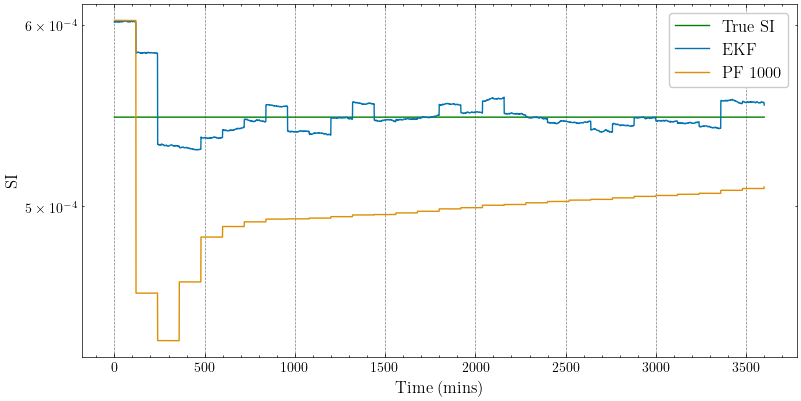

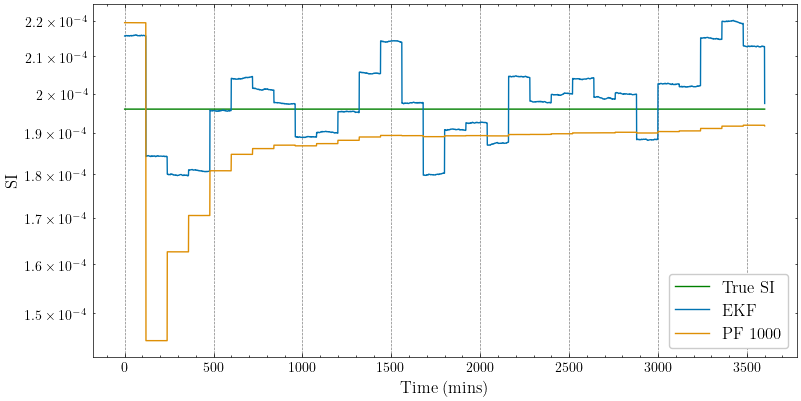

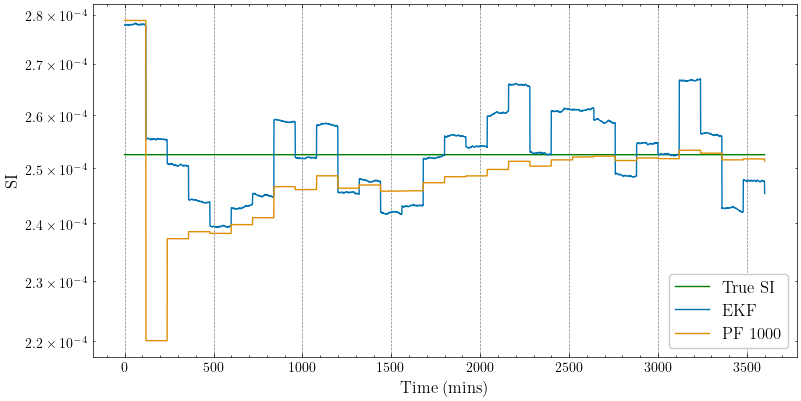

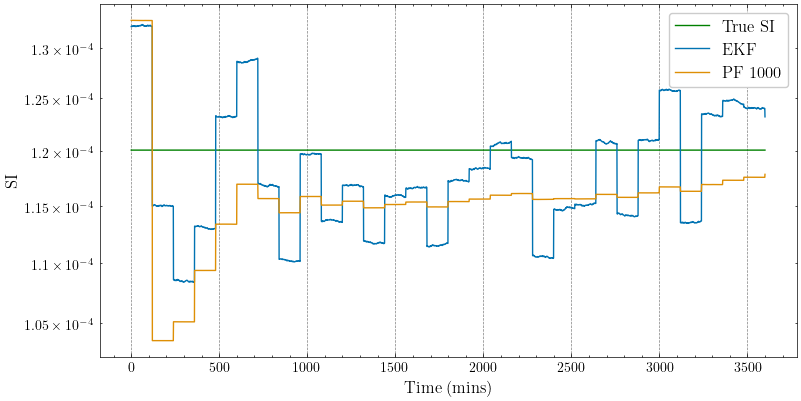

In [36]:
time = np.arange(SI_true_arr.shape[1])
num_filters = len(filters)
palette = sns.color_palette("colorblind", num_filters)
deviation = 0

for i in range(10):
    fig, ax = plt.subplots(figsize=(8,4))
    true_SI = SI_true_arr[i, :]
    ax.semilogy(time, true_SI, color="green", label="True SI")
    for j in range(num_filters):
        patient = i
        est = SI_ests[deviation, j, i, :]
        ax.semilogy(time, est, linestyle="-", color=palette[j], label=f"{filters[j]}")

    ax.set_xlabel("Time (mins)")
    ax.set_ylabel("SI")
    ax.legend()

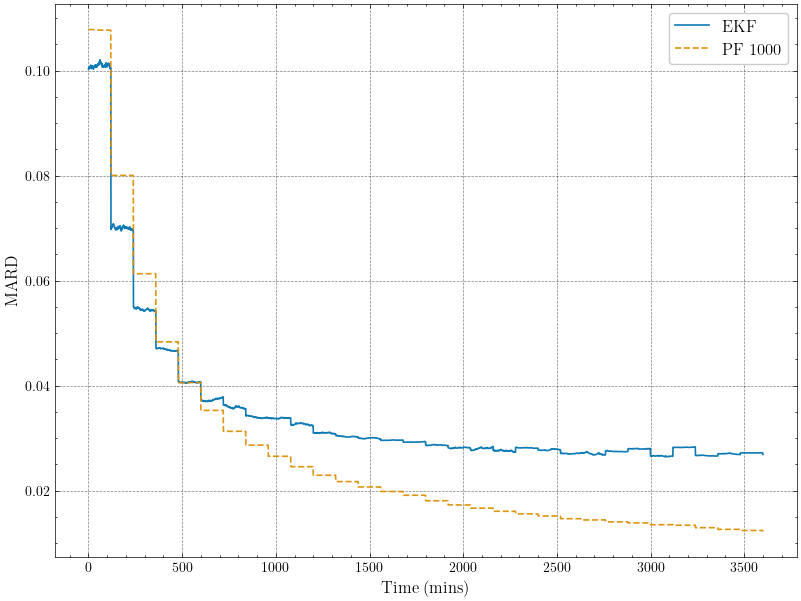

In [37]:
for j in range(num_deviations):
    mean_err = np.mean(SI_errs[j, :, :, :], axis=1)
    ci_low = np.percentile(SI_errs[j, :, :, :], low_perc, axis=1)
    ci_high = np.percentile(SI_errs[j, :, :, :], high_perc, axis=1)
    num_plots = len(filters)
    fig, ax = plt.subplots(figsize=(8,6))

    for i in range(num_plots):
        ax.plot(
            time,
            mean_err[i] / 100,
            color=palette[i],
            linewidth=1.2,
            alpha=0.95,
            linestyle=["-", "--", "-.", ":"][i % 4],
            label=f"{filters[i]}",
        )
    ax.set_ylabel("MARD")
    ax.legend(loc="best")
    ax.set_xlabel("Time (mins)")
    # ax.set_title(f"Initial State Deviation of {dev_perc[j]} %")
    fig.savefig("figures/5_4.pdf", format="pdf")

In [38]:
total_mard = np.average(SI_errs / 100, axis=(2,3))
print("Total MARD: ", total_mard)

Total MARD:  [[0.03502493 0.02698973]]


# Changing SI with State Augmentation 

In [39]:
try:
    SI_ests = np.load("../scripts/variables/SI_ests_augment_vary_04.npy")
    SI_errs = np.load("../scripts/variables/SI_errs_augment_vary_04.npy")
    SI_true_arr = np.load("../scripts/variables/SI_true_arr_augment_vary_04.npy")
    print("Loaded variables")
except Exception:
    print("Run 04_Paramater_estimation_augment_vary.py")

Loaded variables


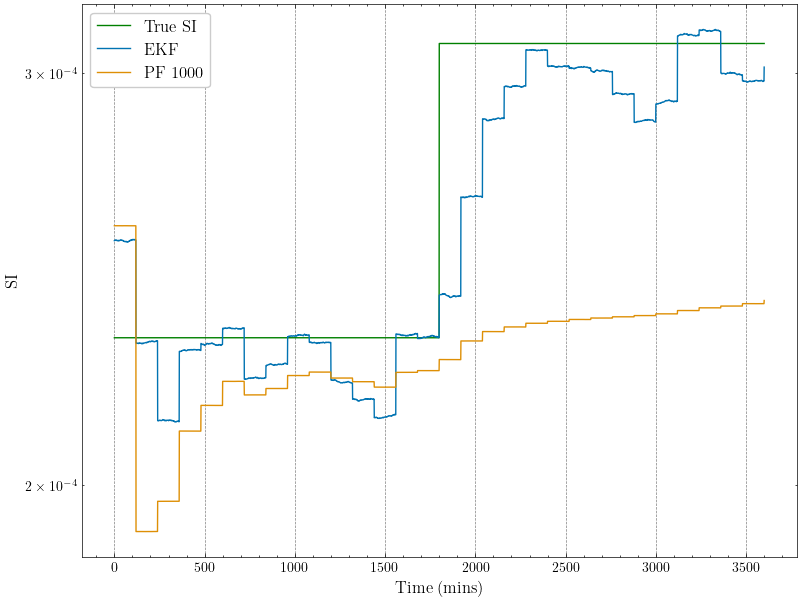

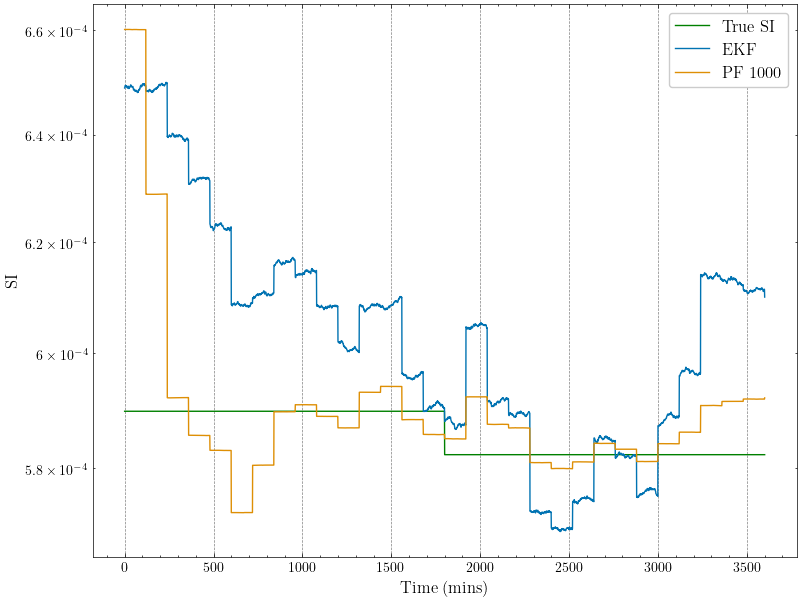

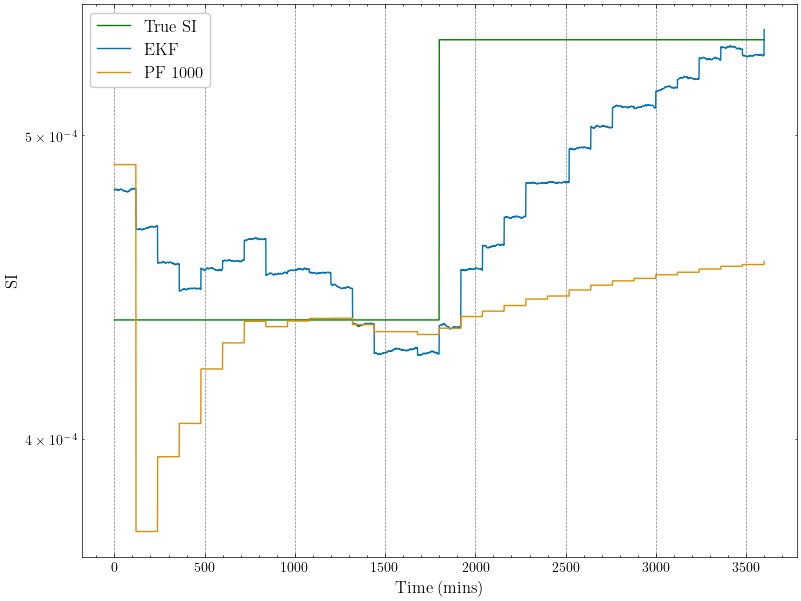

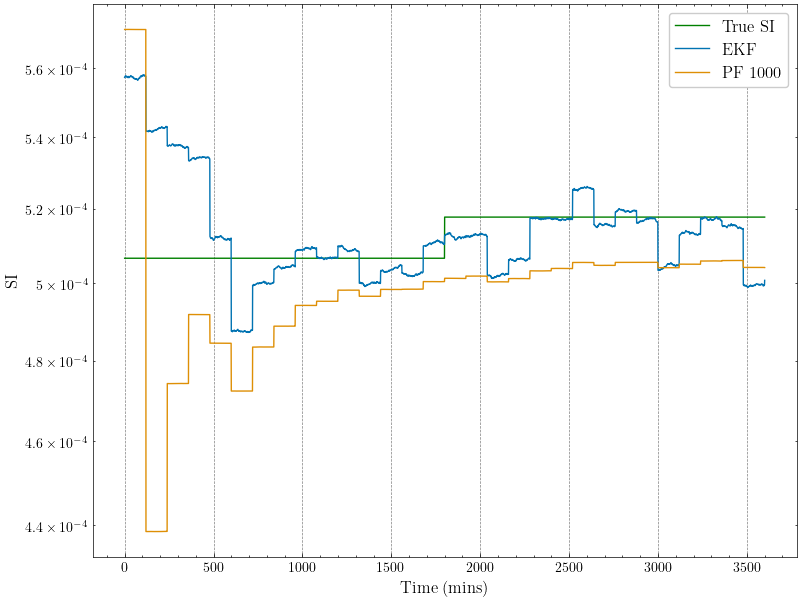

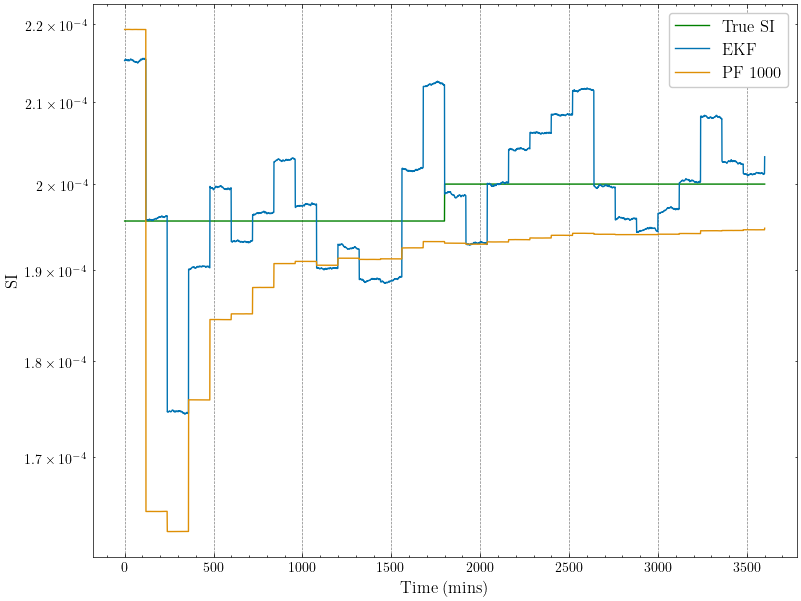

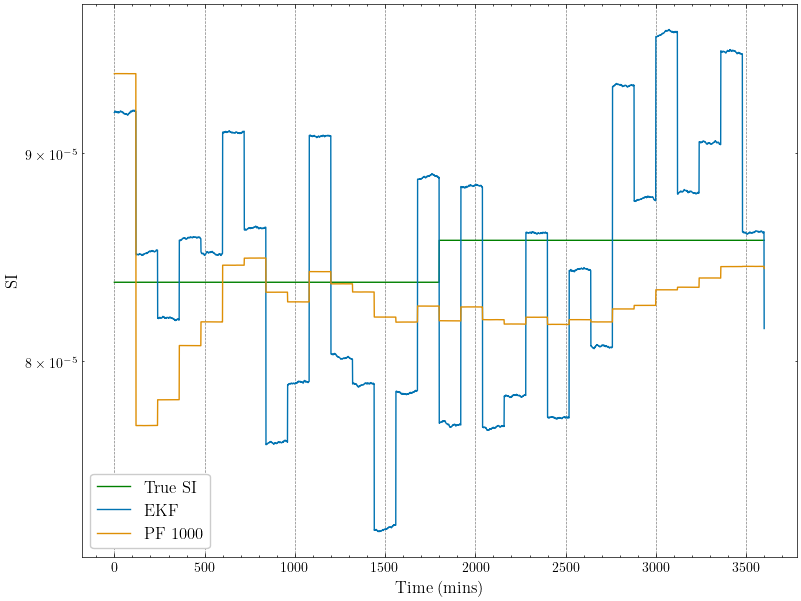

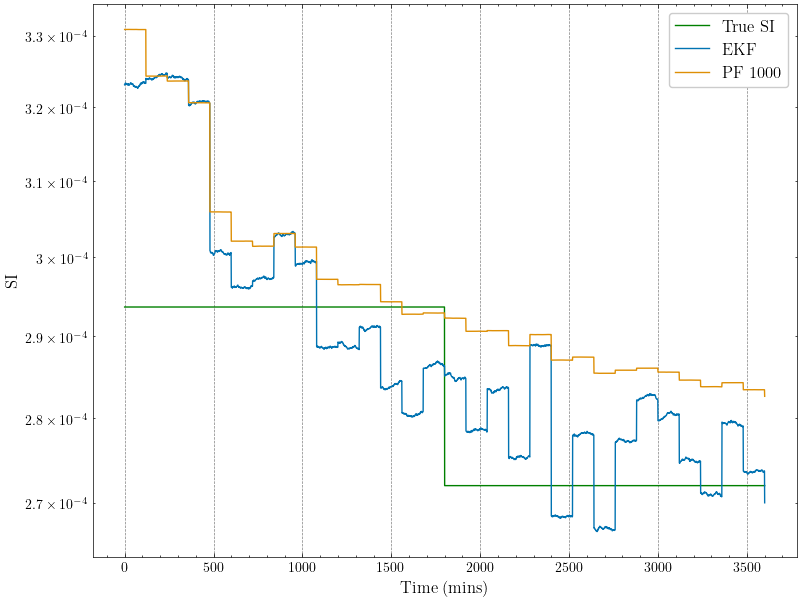

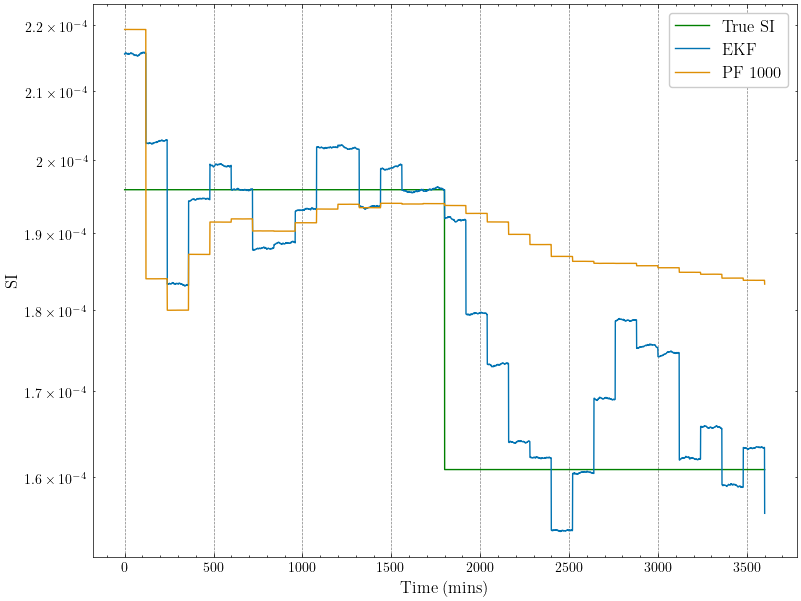

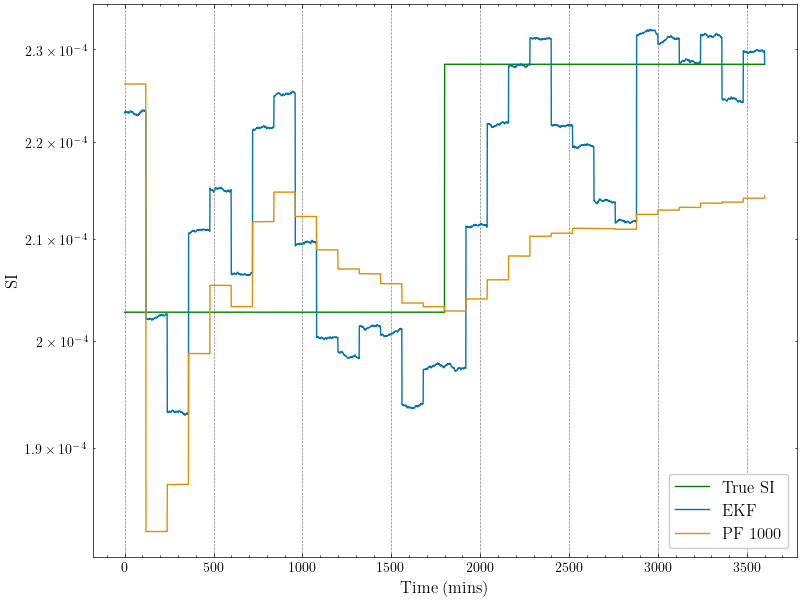

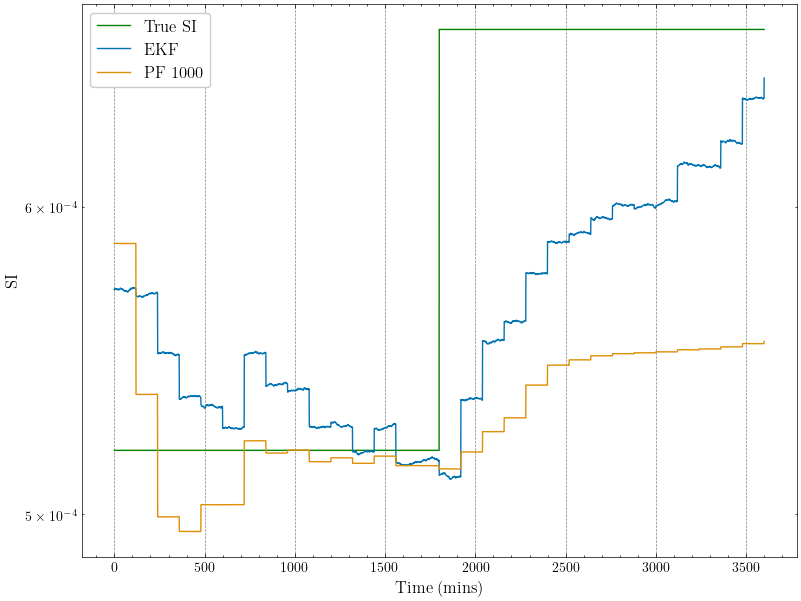

In [40]:
time = np.arange(SI_true_arr.shape[1])
num_filters = len(filters)
palette = sns.color_palette("colorblind", num_filters)
deviation = 0

for i in range(10):
    fig, ax = plt.subplots(figsize=(8,6))
    true_SI = SI_true_arr[i, :]
    ax.semilogy(time, true_SI, color="green", label="True SI")
    for j in range(num_filters):
        patient = i
        est = SI_ests[deviation, j, i, :]
        ax.semilogy(time, est, linestyle="-", color=palette[j], label=f"{filters[j]}")

    ax.set_xlabel("Time (mins)")
    ax.set_ylabel("SI")
    ax.legend()

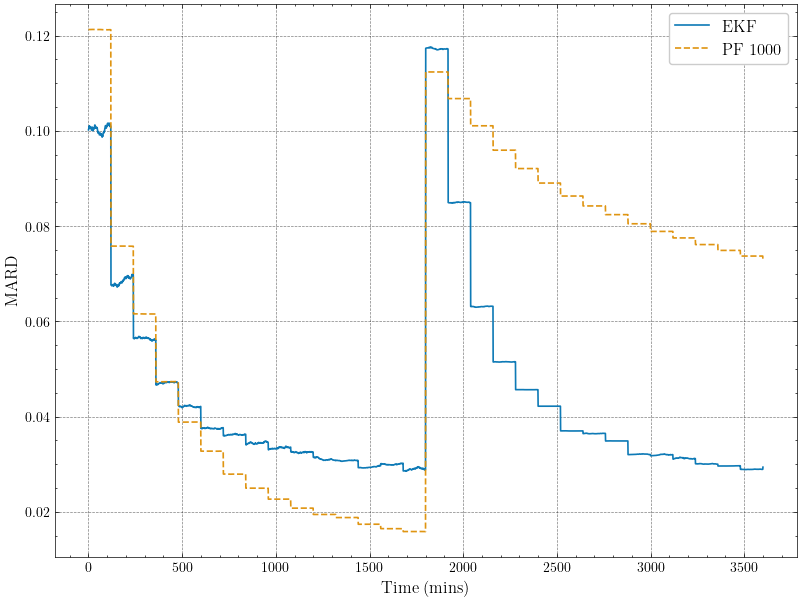

In [41]:
for j in range(num_deviations):
    mean_err = np.mean(SI_errs[j, :, :, :], axis=1)
    time = np.arange(mean_err.shape[1])
    num_plots = len(filters)
    num_filters = len(filters)
    palette = sns.color_palette("colorblind", num_filters)

    fig, ax = plt.subplots(figsize=(8,6))

    for i in range(num_plots):
        ax.plot(
            time,
            mean_err[i] / 100,
            color=palette[i],
            linewidth=1.2,
            alpha=0.95,
            linestyle=["-", "--", "-.", ":"][i % 4],
            label=f"{filters[i]}",
        )
    ax.set_xlabel("Time (mins)")
    ax.set_ylabel("MARD")
    ax.legend(loc="best")
    # ax.set_title(f"Initial State Deviation of {dev_perc[j]} %")
    fig.savefig("figures/5_5.pdf", format="pdf")


In [42]:
total_mard = np.average(SI_errs / 100, axis=(2,3))
print("Total MARD: ", total_mard)

Total MARD:  [[0.0445238  0.06246614]]
